In [1]:
import seaborn as sns
from scipy import stats

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.ticker as ticker

In [2]:
# Paths
df = pd.read_csv('../proccessing_ensemble/lhs_np15_ns3000_values.txt', sep='\s+')
ds = df.to_xarray()
ds = ds.rename({'index': 'sim'})

scores1=xr.open_dataset("./scores/sc_all2.nc")

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2350268/1501707440.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('../proccessing_ensemble/lhs_np15_ns3000_values.txt', sep='\s+')


In [3]:
def figure_scores(scores1,ds,var,scr,scr_name):
    fig, axs = plt.subplots(3, 4, figsize=(13, 8))
    axs = axs.flatten()

    j=0
    for s in scr:
        ax = axs[j]
        score=np.array(scores1[s])
        variable = np.array(ds[var])
        # ax.scatter(variable, score, alpha=0.5,size=3)
        slope, intercept, r_value, p_value, std_err = stats.linregress(variable, score)
        if r_value>0.3 or r_value<-0.3:
            print(f"{var}; {scr_name[j]}: r={r_value:.2f}; p={p_value:.2f}")
            color = "#8BE68B"
        else:
            color = "white"
        sns.regplot(x=variable, y=score,ax=ax, color=".4",line_kws=dict(color="black"),scatter_kws={'s': 8})
        text = f'r = {r_value:.2f}\np = {p_value:.2f}'
        ax.text(0.05, 0.9, text, transform=ax.transAxes, fontsize=8, 
            verticalalignment='top', bbox=dict(facecolor=color, alpha=0.9))
        axs[j].set_ylabel(f"{scr_name[j]}")
        j+=1
              
    for ax in axs:
        ax.set_xlabel(f"{var}")
        ax.grid(which="both",alpha=0.5)
    plt.tight_layout()
    return



In [6]:
vars = ["itm.itm_b","itm.itm_c","ydyn.beta_q","ytill.z0","yneff.delta","ymat.enh_shear","marine_shelf.kappa_grz","isostasy.tau","isostasy.He_lith","ytopo.kt","ytill.cf_negis_centre","ytill.cf_negis_south","ytill.cf_negis_north","snap.f_p_ne","ctrl.cf_negis_1"]
scr=["sc_pd1","sc_pd2","sc_pd3","sc_pd4","sc_pd5","sc_pt1g","sc_pt1n","sc_pt1c","sc_pt1d","sc_pt2","sc_pt4"]
scr_name=["sc_pd1 (H_ice)","sc_pd2 (Ice cover)","sc_pd3 (z_bed)","sc_pd4 (uxy_srf)","sc_pd5 (v_vert)","sc_pt1g (GRIP)","sc_pt1n (NGRIP)","sc_pt1c (Camp Century)","sc_pt1d (DYE3)","sc_pt2 (isochrones)","sc_pt4 (RSL)"]

for var in vars:
    figure_scores(scores1,ds,var,scr,scr_name)
    plt.savefig(f"./figs_scores/score_{var}.png")
    plt.close()

itm.itm_b; sc_pd1 (H_ice): r=-0.41; p=0.00
itm.itm_b; sc_pd2 (Ice cover): r=-0.44; p=0.00
itm.itm_b; sc_pd3 (z_bed): r=-0.33; p=0.00
itm.itm_b; sc_pt2 (isochrones): r=-0.67; p=0.00
itm.itm_c; sc_pd1 (H_ice): r=-0.41; p=0.00
itm.itm_c; sc_pd2 (Ice cover): r=-0.44; p=0.00
itm.itm_c; sc_pd3 (z_bed): r=-0.37; p=0.00
itm.itm_c; sc_pt2 (isochrones): r=-0.61; p=0.00
yneff.delta; sc_pd1 (H_ice): r=0.49; p=0.00
yneff.delta; sc_pd3 (z_bed): r=0.53; p=0.00
yneff.delta; sc_pd4 (uxy_srf): r=-0.82; p=0.00
yneff.delta; sc_pt1g (GRIP): r=-0.42; p=0.00
yneff.delta; sc_pt1c (Camp Century): r=0.40; p=0.00
yneff.delta; sc_pt1d (DYE3): r=0.38; p=0.00
ymat.enh_shear; sc_pt1c (Camp Century): r=-0.66; p=0.00
marine_shelf.kappa_grz; sc_pd2 (Ice cover): r=-0.45; p=0.00
isostasy.tau; sc_pt4 (RSL): r=-0.85; p=0.00
isostasy.He_lith; sc_pd5 (v_vert): r=-0.72; p=0.00


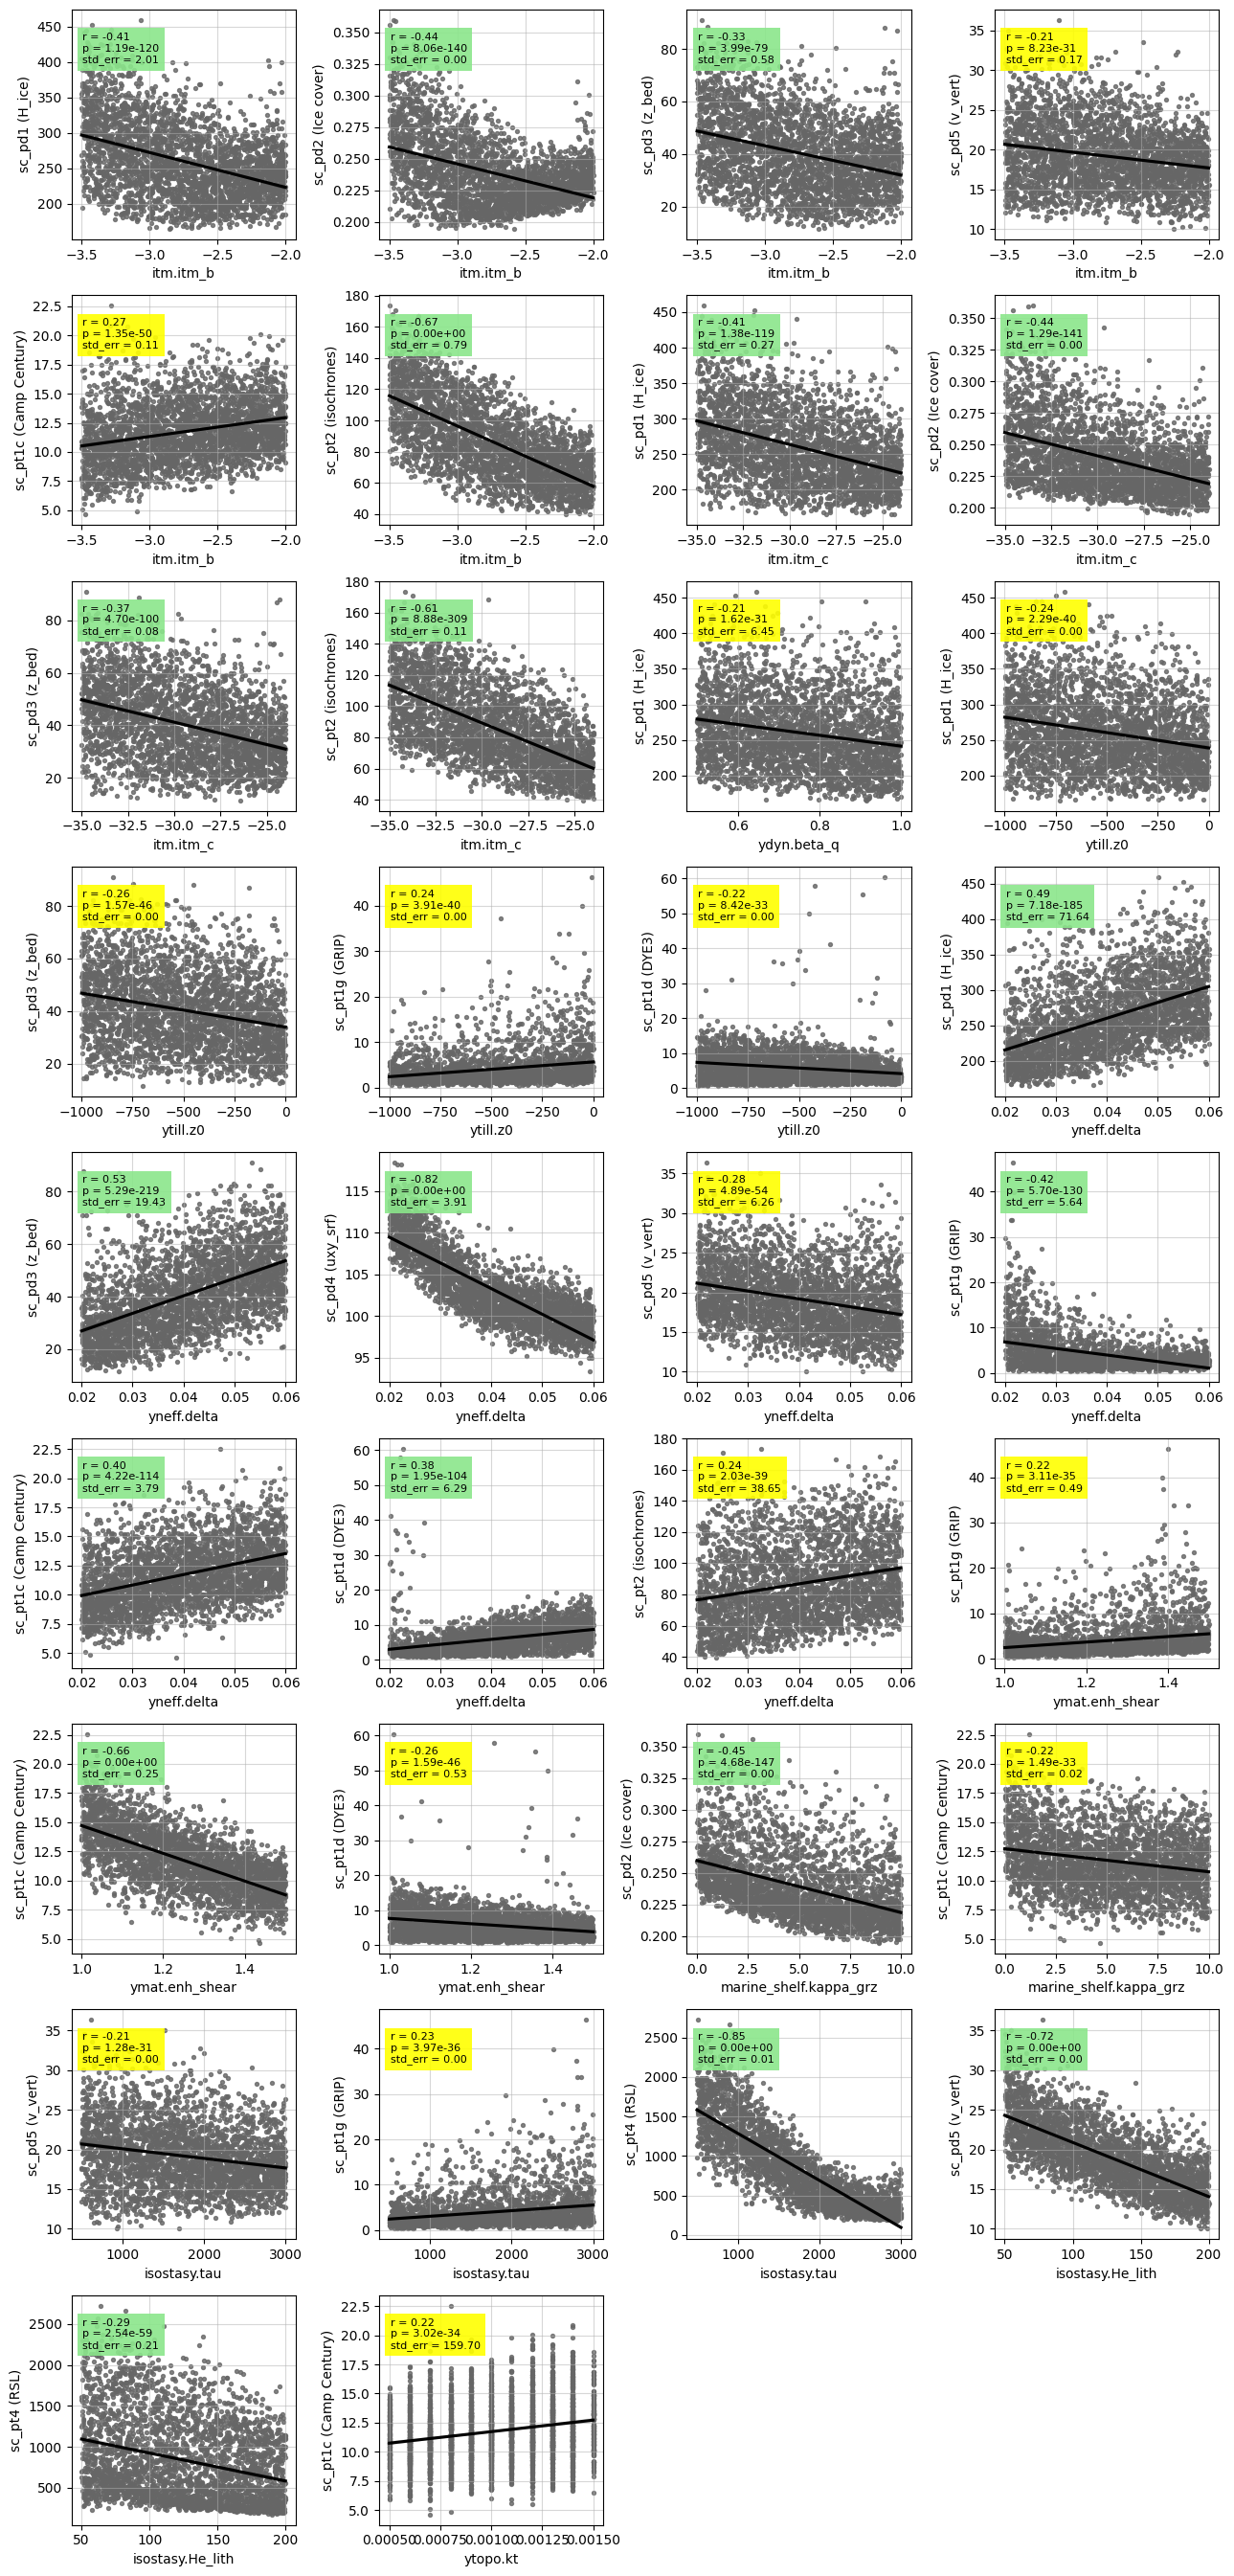

In [18]:
def figure_best_correlations(scores1, ds, vars_list, scr, scr_name,lim_r=0.3):
    best_matches = []

    for var in vars_list:
        for j, s in enumerate(scr):
            score = np.array(scores1[s])
            variable = np.array(ds[var])
            slope, intercept, r_value, p_value, std_err = stats.linregress(variable, score)
            
            if abs(r_value) > lim_r:
                best_matches.append({
                    'var': var,
                    'score_val': score,
                    'variable_val': variable,
                    'scr_label': scr_name[j],
                    'r': r_value,
                    'p': p_value,
                    "std_err": std_err
                })

    n_plots = len(best_matches)
    cols = 4
    rows = (n_plots + cols - 1) // cols
    
    fig, axs = plt.subplots(rows, cols, figsize=(13, 3 * rows))
    axs = np.array(axs).flatten() 

    for i, match in enumerate(best_matches):
        ax = axs[i]
        sns.regplot(x=match['variable_val'], y=match['score_val'], ax=ax, 
                    color=".4", line_kws=dict(color="black"), scatter_kws={'s': 8})
        
        text = f'r = {match["r"]:.2f}\np = {match["p"]:.2e}\nstd_err = {match["std_err"]:.2f}'
        if abs(match["r"])>0.29:
            color="#8BE68B"
        else:
            color="yellow"
                
        ax.text(0.05, 0.9, text, transform=ax.transAxes, fontsize=8, 
                verticalalignment='top', bbox=dict(facecolor=color, alpha=0.9, edgecolor='none'))
        ax.set_xlabel(f"{match['var']}")
        ax.set_ylabel(f"{match['scr_label']}")
        ax.grid(which="both", alpha=0.5)

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.savefig("./figs_scores/best_correlations_all2.png")
    plt.show()

figure_best_correlations(scores1, ds, vars, scr, scr_name,lim_r=0.2)

In [16]:
def figure_scores_by_proxy(scores1,ds,vars,s,scr_name):
    fig, axs = plt.subplots(4, 4, figsize=(13, 10))
    axs = axs.flatten()
    j=0
    for var in vars:
        ax = axs[j]
        score=np.array(scores1[s])
        variable = np.array(ds[var])
        # ax.scatter(variable, score, alpha=0.5,size=3)
        slope, intercept, r_value, p_value, std_err = stats.linregress(variable, score)
        if r_value>0.3 or r_value<-0.3:
            print(f"{var}; {scr_name}: r={r_value:.2f}; p={p_value:.2f}")
            color = "#8BE68B"
        else:
            color = "white"
        sns.regplot(x=variable, y=score,ax=ax, color=".4",line_kws=dict(color="black"),scatter_kws={'s': 8})
        text = f'r = {r_value:.2f}\np = {p_value:.2f}'
        ax.text(0.05, 0.9, text, transform=ax.transAxes, fontsize=8, 
            verticalalignment='top', bbox=dict(facecolor=color, alpha=0.9))
        axs[j].set_ylabel(f"{scr_name}")
        ax.set_xlabel(f"{var}")
        j+=1
              
    for ax in axs:
        ax.grid(which="both",alpha=0.5)
    plt.tight_layout()
    return


i=0
for s in scr:
    figure_scores_by_proxy(scores1,ds,vars,s,scr_name[i])
    plt.savefig(f"./figs_scores/score_by_proxy_{s}.png")
    plt.close()
    i+=1

itm.itm_b; sc_pd1 (H_ice): r=-0.41; p=0.00
itm.itm_c; sc_pd1 (H_ice): r=-0.41; p=0.00
yneff.delta; sc_pd1 (H_ice): r=0.49; p=0.00
itm.itm_b; sc_pd2 (Ice cover): r=-0.44; p=0.00
itm.itm_c; sc_pd2 (Ice cover): r=-0.44; p=0.00
marine_shelf.kappa_grz; sc_pd2 (Ice cover): r=-0.45; p=0.00
itm.itm_b; sc_pd3 (z_bed): r=-0.33; p=0.00
itm.itm_c; sc_pd3 (z_bed): r=-0.37; p=0.00
yneff.delta; sc_pd3 (z_bed): r=0.53; p=0.00
yneff.delta; sc_pd4 (uxy_srf): r=-0.82; p=0.00
isostasy.He_lith; sc_pd5 (v_vert): r=-0.72; p=0.00
yneff.delta; sc_pt1g (GRIP): r=-0.42; p=0.00
yneff.delta; sc_pt1c (Camp Century): r=0.40; p=0.00
ymat.enh_shear; sc_pt1c (Camp Century): r=-0.66; p=0.00
yneff.delta; sc_pt1d (DYE3): r=0.38; p=0.00
itm.itm_b; sc_pt2 (isochrones): r=-0.67; p=0.00
itm.itm_c; sc_pt2 (isochrones): r=-0.61; p=0.00
isostasy.tau; sc_pt4 (RSL): r=-0.85; p=0.00


In [13]:
vars

['itm.itm_b',
 'itm.itm_c',
 'ydyn.beta_q',
 'ytill.z0',
 'yneff.delta',
 'ymat.enh_shear',
 'marine_shelf.kappa_grz',
 'isostasy.tau',
 'isostasy.He_lith',
 'ytopo.kt',
 'ytill.cf_negis_centre',
 'ytill.cf_negis_south',
 'ytill.cf_negis_north',
 'snap.f_p_ne',
 'ctrl.cf_negis_1']